# Linear Regression with One Variable

### Using Matrix (Normal Equation)


In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()


In [ ]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
print(iris.feature_names)


['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [ ]:
# Feature (X): sepal length (column 0), first 50 samples
X = iris.data[:50, 0].reshape(-1, 1)

# Target (y): sepal width (column 1)
y = iris.data[:50, 1]


In [ ]:
import numpy as np

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # shape (50, 2)

In [ ]:
# Normal equation: weights = (X^T X)^(-1) X^T y
weight_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

print("Intercept (w0):", weight_best[0])
print("Slope (w1):", weight_best[1])

Intercept (w0): -0.5694326730399227
Slope (w1): 0.7985283006471879


In [ ]:
# Predictions using learned weights
y_pred = X_b.dot(weight_best)
y_pred

array([3.50306166, 3.343356  , 3.18365034, 3.10379751, 3.42320883,
       3.74262015, 3.10379751, 3.42320883, 2.94409185, 3.343356  ,
       3.74262015, 3.26350317, 3.26350317, 2.86423902, 4.06203147,
       3.98217864, 3.74262015, 3.50306166, 3.98217864, 3.50306166,
       3.74262015, 3.50306166, 3.10379751, 3.50306166, 3.26350317,
       3.42320883, 3.42320883, 3.58291449, 3.58291449, 3.18365034,
       3.26350317, 3.74262015, 3.58291449, 3.82247298, 3.343356  ,
       3.42320883, 3.82247298, 3.343356  , 2.94409185, 3.50306166,
       3.42320883, 3.02394468, 2.94409185, 3.42320883, 3.50306166,
       3.26350317, 3.50306166, 3.10379751, 3.66276732, 3.42320883])

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# Evaluation Metrics
print("R² Score:", r2_score(y, y_pred))
print("Mean Squared Error:", mean_squared_error(y, y_pred))

R² Score: 0.5513755803923134
Mean Squared Error: 0.06317349627147602


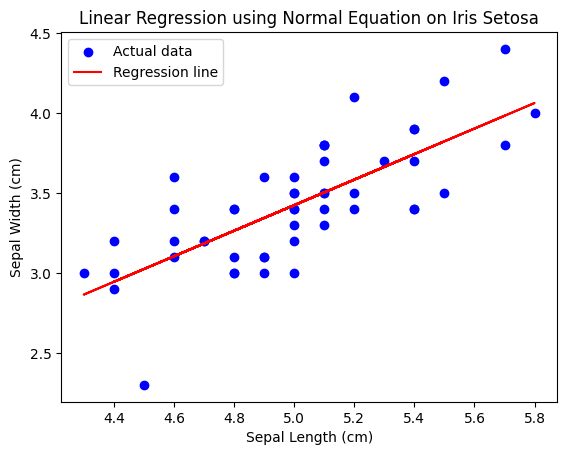

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color="blue", label="Actual data")
plt.plot(X, y_pred, color="red", label="Regression line")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.legend()
plt.title("Linear Regression using Normal Equation on Iris Setosa")
plt.show()


### Using Package


In [ ]:
from sklearn.linear_model import LinearRegression


Intercept (w0): -0.569432673039648
Slope (w1): 0.798528300647153
R² Score: 0.5513755803923133
Mean Squared Error: 0.06317349627147602


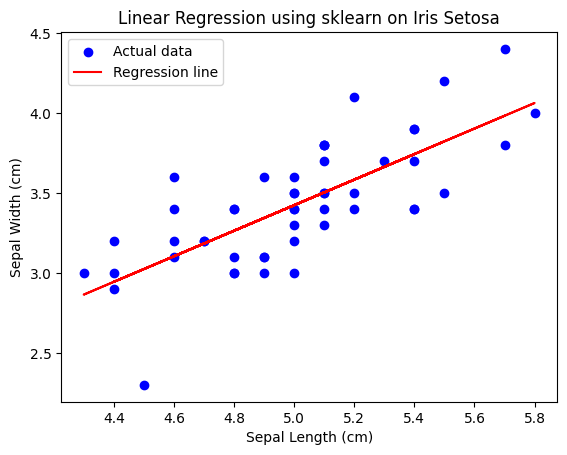

In [ ]:
# Load Iris dataset
iris = load_iris()
X = iris.data[:50, 0].reshape(-1, 1)   # Sepal length (first 50 samples = Setosa)
y = iris.data[:50, 1]                  # Sepal width

# Fit Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Extract coefficients
w = model.coef_[0]       # slope
c = model.intercept_     # intercept

print("Intercept (w0):", c)
print("Slope (w1):", w)

# Predictions using learned weights
y_pred = model.predict(X)

# Evaluation Metrics
print("R² Score:", r2_score(y, y_pred))
print("Mean Squared Error:", mean_squared_error(y, y_pred))

# Plot scatter and regression line
plt.scatter(X, y, color="blue", label="Actual data")
plt.plot(X, y_pred, color="red", label="Regression line")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.legend()
plt.title("Linear Regression using sklearn on Iris Setosa")
plt.show()

### Covariance method


Intercept (w0): -0.5694326730396497
Slope (w1): 0.7985283006471533
R² Score: 0.5513755803923133
Mean Squared Error: 0.06317349627147602


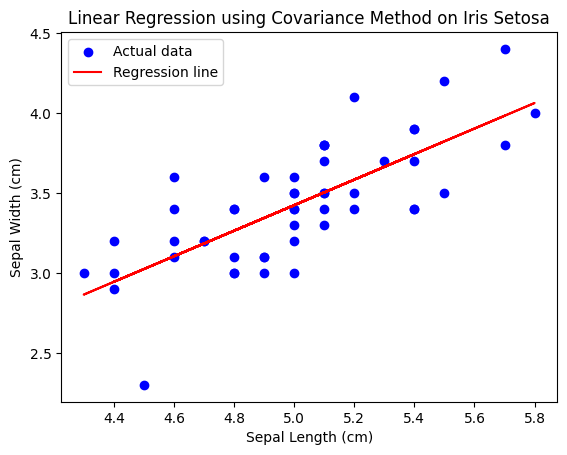

In [ ]:
# Load Iris dataset
iris = load_iris()
X = iris.data[:50, 0]   # Sepal length (Setosa)
y = iris.data[:50, 1]   # Sepal width

# Compute slope using covariance/variance
w = np.cov(X, y, bias=True)[0, 1] / np.var(X)
c = np.mean(y) - w * np.mean(X)

print("Intercept (w0):", c)
print("Slope (w1):", w)

# Predictions
y_pred = c + w * X

# Evaluation metrics
print("R² Score:", r2_score(y, y_pred))
print("Mean Squared Error:", mean_squared_error(y, y_pred))

# Plot scatter and regression line
plt.scatter(X, y, color="blue", label="Actual data")
plt.plot(X, y_pred, color="red", label="Regression line")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.legend()
plt.title("Linear Regression using Covariance Method on Iris Setosa")
plt.show()

### Using iterative Method (Gradient Descent)


Intercept (w0): 1.2041444046591532
Slope (w1): 0.44588602805819044
R² Score: 0.4433607675001574
Mean Squared Error: 0.07838371016369786


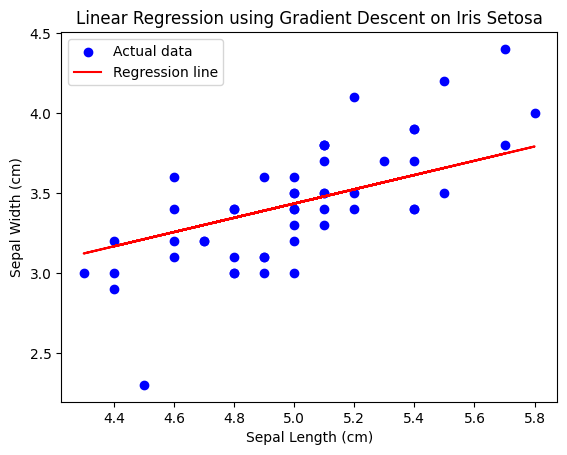

In [ ]:
# Load Iris dataset
iris = load_iris()
X = iris.data[:50, 0].reshape(-1, 1)   # Sepal length
y = iris.data[:50, 1]                  # Sepal width

# Add bias term (intercept column of ones)
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # shape (50,2)

# Gradient Descent parameters
learning_rate = 0.01
n_iterations = 1000
m = len(y)

# Initialize weights (intercept + slope)
weights = np.random.randn(2)

# Gradient Descent loop
for iteration in range(n_iterations):
    gradients = (2/m) * X_b.T.dot(X_b.dot(weights) - y)
    weights = weights - learning_rate * gradients

# Extract coefficients
c = weights[0]   # intercept
w = weights[1]   # slope

print("Intercept (w0):", c)
print("Slope (w1):", w)

# Predictions using learned weights
y_pred = X_b.dot(weights)

# Evaluation Metrics
print("R² Score:", r2_score(y, y_pred))
print("Mean Squared Error:", mean_squared_error(y, y_pred))

# Plot scatter and regression line
plt.scatter(X, y, color="blue", label="Actual data")
plt.plot(X, y_pred, color="red", label="Regression line")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.legend()
plt.title("Linear Regression using Gradient Descent on Iris Setosa")
plt.show()
